In [1]:
import pandas as pd
import spacy
from collections import Counter

# CONFIGURATION
INPUT = "/home/ensai/Cours/PFE/Topic-modeling-with-NLP/data/makeorg_biodiversite.xlsx" # Path to the dataset
OUTPUT = "output.xlsx"
TEXT_COL = "Proposition"
NEW_COL = "Tokens_lemmas"
MODEL = "fr_core_news_lg" 

# READ DATA
df = pd.read_excel(INPUT)

if TEXT_COL not in df.columns:
    raise ValueError(f"Column '{TEXT_COL}' not found. Available: {list(df.columns)}")

# Remove leading "Il faut …"
df[TEXT_COL] = df[TEXT_COL].str.replace(r'^\s*Il faut\s+', '', case=False, regex=True)

# LOAD MODEL
nlp = spacy.load(MODEL)

# Stopwords personnalisés (plus sélectifs)
CUSTOM_STOPWORDS = {
    'être', 'avoir', 'faire', 'pouvoir', 'devoir', 'vouloir',
    'aller', 'mettre', 'prendre', 'dire', 'savoir', 'voir',
    'celui', 'celle', 'ceux', 'celles', 'ceci', 'cela',
    'le', 'la', 'les', 'un', 'une', 'des', 'du', 'de',
    'ce', 'cette', 'ces', 'mon', 'ma', 'mes', 'ton', 'ta', 'tes',
    'son', 'sa', 'ses', 'notre', 'nos', 'votre', 'vos', 'leur', 'leurs',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
    'me', 'te', 'se', 'lui', 'leur', 'en', 'y',
    'qui', 'que', 'quoi', 'dont', 'où',
    'et', 'ou', 'mais', 'donc', 'car', 'ni', 'or',
    'à', 'dans', 'par', 'pour', 'sous', 'sur', 'vers',
    'aussi', 'pas'
}

def doc_to_lemmas(doc):
    """
    Extrait les lemmes pertinents pour l'analyse sémantique
    Focus sur: NOUN, VERB, ADJ, ADV principalement
    """
    lemmas = []
    
    for tok in doc:
        # Skip ponctuation et espaces
        if tok.is_punct or tok.is_space:
            continue
        
        # Skip nombres
        if tok.like_num or tok.is_digit:
            continue
        
        # Skip tokens non-alphabétiques (sauf si composés avec tiret)
        if not tok.is_alpha and '-' not in tok.text:
            continue
        
        # Skip si trop court (souvent du bruit)
        if len(tok.text) < 3:
            continue
        
        # Filtrage par POS (Part-of-Speech)
        # Gardez les mots porteurs de sens
        if tok.pos_ not in ['NOUN', 'VERB', 'ADJ', 'PROPN', 'ADV']:
            continue
        
        # Lemmatisation
        lemma = tok.lemma_.lower().strip()
        
        # Skip stopwords personnalisés
        if lemma in CUSTOM_STOPWORDS:
            continue
        
        # Skip si le lemma est vide ou trop court après nettoyage
        if len(lemma) < 3:
            continue
        
        lemmas.append(lemma)
    
    return lemmas

# PROCESS TEXTS
print("Traitement des textes...")
texts = df[TEXT_COL].astype(str).fillna("").tolist()

# Utilisez parser pour avoir les POS tags corrects
docs = nlp.pipe(texts, disable=["ner"])  # Gardez le parser !

df[NEW_COL] = [doc_to_lemmas(doc) for doc in docs]

# Filtrer les propositions vides
df = df[df[NEW_COL].map(len) > 0].reset_index(drop=True)

print(f"{len(df)} propositions traitées")
print(f"\nExemples de lemmatisation:")
print(df[[TEXT_COL, NEW_COL]].head(10))

# Statistiques sur le vocabulaire
all_lemmas = [lemma for lemmas in df[NEW_COL] for lemma in lemmas]
vocab_size = len(set(all_lemmas))
avg_length = sum(len(lemmas) for lemmas in df[NEW_COL]) / len(df)

print(f"\n Statistiques:")
print(f"  - Vocabulaire total: {vocab_size} lemmes uniques")
print(f"  - Longueur moyenne: {avg_length:.1f} lemmes/proposition")
print(f"  - Total tokens: {len(all_lemmas)}")

# Top lemmes les plus fréquents
lemma_counts = Counter(all_lemmas)
print(f"\n Top 20 lemmes:")
for lemma, count in lemma_counts.most_common(20):
    print(f"  {lemma}: {count}")

Traitement des textes...
5554 propositions traitées

Exemples de lemmatisation:
                                         Proposition  \
0  favoriser le reboisement urbain afin de baisse...   
1  stopper l’érosion des haies (-23 500km par an)...   
2  stopper l'importation de produits agricoles tr...   
3  réintégrer les arbres et les haies dans l’agri...   
4  empêcher l'importation de produits agricoles q...   
5  replanter des haies pour éviter l'érosion des ...   
6  punir sévèrement ceux qui déversent des déchet...   
7  replanter des haies autour des champs afin de ...   
8  préserver, restaurer, maintenir en bon état éc...   
9  soutenir une agriculture protectrice du vivant...   

                                       Tokens_lemmas  
0  [favoriser, reboisement, urbain, afin, baisser...  
1  [stopper, érosion, haie, puissant, levier, tra...  
2  [stopper, importation, produit, agricole, trai...  
3  [réintégrer, arbre, haie, agriculture, produir...  
4  [empêcher, importation, p

## Now we will define an evaluation_embedding funtion that will test the our embeddings similarities

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

def evaluate_embedding(model, sentences, n_sample_words=10, topn=10):
    """
    Evaluate the embeddings of our model
    
    Args:
        model: the trained model
        sentences: sentences of the 
        n_sample_words: number of words sampled for test
        topn: Number of similar words to display
        
    Returns:
        dict: Dict for metrics and examples
    """
    results = {
        'metrics': {},
        'examples': {}
    }
    
    # Récupérer tous les mots du vocabulaire
    all_words = [w for sent in sentences for w in sent]
    word_freq = Counter(all_words)
    vocab_words = [w for w in word_freq.keys() if w in model.wv]
    
    if len(vocab_words) == 0:
        print("Aucun mot trouvé dans le vocabulaire du modèle!")
        return results
    
    # === MÉTRIQUES ===
    
    # 1. Couverture du vocabulaire
    unique_words = len(set(all_words))
    vocab_size = len(model.wv)
    results['metrics']['vocab_coverage'] = vocab_size / unique_words
    results['metrics']['vocab_size'] = vocab_size
    
    # 2. Similarity quality
    # We must then sample words of different frequences
    frequent_words = [w for w, c in word_freq.most_common(50) if w in model.wv]
    rare_words = [w for w, c in word_freq.most_common()[-50:] if w in model.wv]
    
    ## moins bonne estimation
    sample_words = []
    if len(frequent_words) >= n_sample_words // 2:
        sample_words.extend(np.random.choice(frequent_words, n_sample_words // 2, replace=False))
    if len(rare_words) >= n_sample_words // 2:
        sample_words.extend(np.random.choice(rare_words, n_sample_words // 2, replace=False))
    
    # Calculer les statistiques de similarité
    all_similarities = []
    max_similarities = []
    
    for word in sample_words:
        try:
            similar = model.wv.most_similar(word, topn=topn)
            sims = [sim for _, sim in similar]
            all_similarities.extend(sims)
            max_similarities.append(max(sims)) 
        except:
            continue
    
    results['metrics']['avg_similarity'] = np.mean(all_similarities) if all_similarities else 0.0
    results['metrics']['std_similarity'] = np.std(all_similarities) if all_similarities else 0.0
    results['metrics']['avg_max_similarity'] = np.mean(max_similarities) if max_similarities else 0.0
    
    ###### frequent and rare :
    # 3. Densité de l'espace vectoriel
    sample_vectors = [model.wv[w] for w in sample_words[:20] if w in model.wv]
    if len(sample_vectors) > 1:
        distances = []
        for i in range(len(sample_vectors)):
            for j in range(i + 1, len(sample_vectors)):
                dist = euclidean(sample_vectors[i], sample_vectors[j])
                distances.append(dist)
        results['metrics']['avg_distance'] = np.mean(distances)
        results['metrics']['std_distance'] = np.std(distances)
    
    # === EXEMPLES QUALITATIFS ===
    
    # Sélectionner des mots intéressants pour les exemples
    # Mix de mots fréquents et moyennement fréquents
    test_words = []
    if len(frequent_words) >= 3:
        test_words.extend(frequent_words[:3])
    if len(vocab_words) >= 5:
        mid_freq_words = [w for w in vocab_words if 10 <= word_freq[w] <= 100]
        if len(mid_freq_words) >= 2:
            test_words.extend(np.random.choice(mid_freq_words, min(2, len(mid_freq_words)), replace=False))
    
    for word in test_words:
        if word in model.wv:
            try:
                similar = model.wv.most_similar(word, topn=topn)
                results['examples'][word] = similar
            except:
                continue
    
    # === AFFICHAGE ===
    
    print("\n" + "="*70)
    print("ÉVALUATION DES EMBEDDINGS")
    print("="*70)
    
    print("\n--- MÉTRIQUES ---")
    print(f"Taille du vocabulaire: {results['metrics']['vocab_size']}")
    print(f"Couverture: {results['metrics']['vocab_coverage']:.2%}")
    print(f"Similarité moyenne: {results['metrics']['avg_similarity']:.4f}")
    print(f"Écart-type similarité: {results['metrics']['std_similarity']:.4f}")
    print(f"Similarité max moyenne: {results['metrics']['avg_max_similarity']:.4f}")
    if 'avg_distance' in results['metrics']:
        print(f"Distance moyenne: {results['metrics']['avg_distance']:.4f}")
    
    print("\n--- EXEMPLES DE MOTS SIMILAIRES ---")
    for word, similar_words in results['examples'].items():
        freq = word_freq[word]
        print(f"\n'{word}' (fréquence: {freq}):")
        for similar_word, score in similar_words:
            print(f"  → {similar_word:20s} {score:.4f}")
    
    # Score composite simple pour comparaison
    composite_score = (
        results['metrics']['avg_similarity'] * 0.5 +
        results['metrics']['avg_max_similarity'] * 0.3 +
        (1 - results['metrics']['std_similarity']) * 0.2
    )
    results['metrics']['composite_score'] = composite_score
    
    print(f"\n{'='*70}")
    print(f"SCORE COMPOSITE: {composite_score:.4f}")
    print(f"{'='*70}\n")
    
    return results

########################################################################################""
## plongement sémantique sentenceBERT
## Indice de Jacquart
#############################################################################################


# Évaluation
# # results = evaluate_embedding(model, sentences, n_sample_words=10, topn=10)

# # Accéder aux résultats si besoin
# print(f"\nScore final: {results['metrics']['composite_score']:.4f}, \nAverage Similarity: {results['metrics']['avg_similarity']}")

## Hyperparameter tuning 


In [ ]:
from gensim.models import Word2Vec
from collections import Counter
import numpy as np

SEED = 42
sentences = df[NEW_COL].tolist()

# ================================================
# 2) Hyperparameters 
# ================================================
vector_sizes = [20, 30, 50, 70, 100, 128]
epochs_list = [5, 15, 20]
sg_values = [0, 1]             # CBOW and Skip-gram
window = 14                    # fixed
negative = 4                   # fixed

print("Testing combinations:")
print("vector_sizes:", vector_sizes)
print("epochs:", epochs_list)
print("sg:", sg_values)
print("window:", window)
print("negative:", negative)

# ================================================
# 3) GRID SEARCH
# ================================================
best_score = float('-inf')
best_params = None
best_model = None

for vs in vector_sizes:
    for ep in epochs_list:
        for sg in sg_values:

            print(f"\nTesting: vector_size={vs}, epochs={ep}, sg={sg}")

            model = Word2Vec(
                sentences=sentences,
                vector_size=vs,
                window=window,
                min_count=2,
                sg=sg,
                negative=negative,
                workers=4,
                epochs=ep,
                seed=SEED
            )

            # 'sentences' en 2e argument
            results = evaluate_embedding(model, sentences, n_sample_words=10, topn=10)
            score = results['metrics']['composite_score']  # Récupère le score composite
            print(f"Score = {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = (vs, ep, sg)
                best_model = model
                print("➡ New best model found!")

# ================================================
# 4) PRINT BEST RESULT
# ================================================
print("\n============================")
print("BEST HYPERPARAMETERS FOUND:")
print(f"vector_size = {best_params[0]}")
print(f"epochs      = {best_params[1]}")
print(f"sg          = {best_params[2]}  (0=CBOW, 1=Skip-gram)")
print(f"score       = {best_score:.4f}")
print("============================")

### chasse, enfant, 

Testing combinations:
vector_sizes: [20, 30, 50, 70, 100, 128]
epochs: [5, 15, 20]
sg: [0, 1]
window: 14
negative: 4

Testing: vector_size=20, epochs=5, sg=0

ÉVALUATION DES EMBEDDINGS

--- MÉTRIQUES ---
Taille du vocabulaire: 3255
Couverture: 54.95%
Similarité moyenne: 0.9993
Écart-type similarité: 0.0002
Similarité max moyenne: 0.9995
Distance moyenne: 0.7356

--- EXEMPLES DE MOTS SIMILAIRES ---

'biodiversité' (fréquence: 689):
  → sensibiliser         0.9996
  → donner               0.9995
  → nature               0.9995
  → local                0.9995
  → plus                 0.9994
  → afin                 0.9994
  → non                  0.9994
  → même                 0.9994
  → promouvoir           0.9994
  → limiter              0.9993

'interdire' (fréquence: 650):
  → espèce               0.9995
  → chasse               0.9995
  → chasseur             0.9994
  → citoyen              0.9994
  → limiter              0.9994
  → humain               0.9993
  → protéger          

### Clustering and then Visualizing


 Création des vecteurs de propositions (128D)...
Shape des embeddings: (5554, 128)

 Recherche du nombre optimal de clusters (dans l'espace 128D)...
  k=5: silhouette=0.511
  k=6: silhouette=0.508
  k=7: silhouette=0.502
  k=8: silhouette=0.500
  k=9: silhouette=0.495
  k=10: silhouette=0.486
  k=11: silhouette=0.493
  k=12: silhouette=0.486
  k=13: silhouette=0.482
  k=14: silhouette=0.476
  k=15: silhouette=0.474
  k=16: silhouette=0.468
  k=17: silhouette=0.467
  k=18: silhouette=0.457
  k=19: silhouette=0.450
  k=20: silhouette=0.449


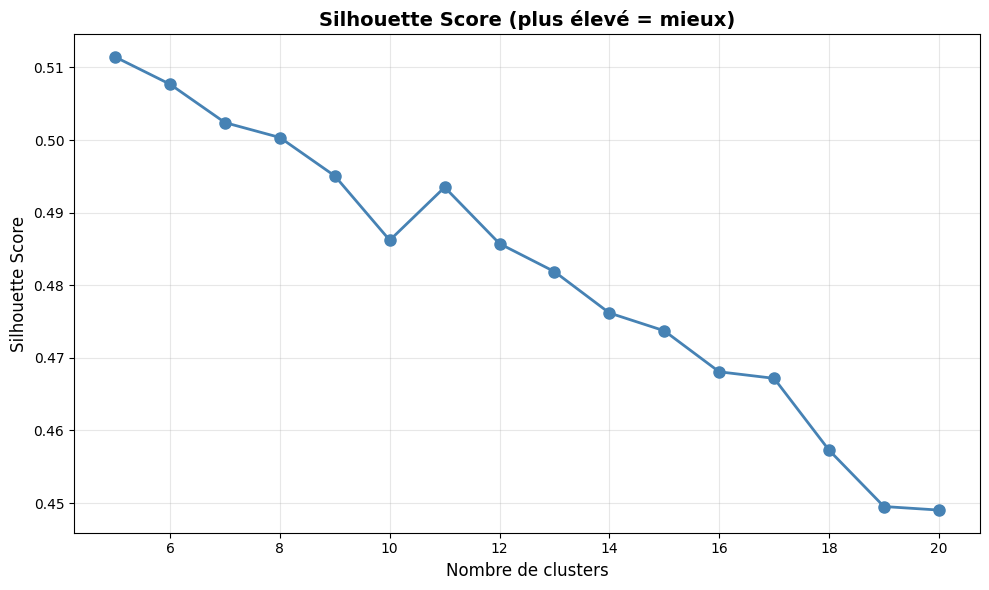


 Meilleur k selon Silhouette: 5
   Score: 0.511

 Clustering final avec k=5 (dans l'espace 128D)
 Clustering effectué dans l'espace 128D


In [31]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from collections import Counter

def proposition_to_vector(lemmas, best_model):
    """
    Moyenne des vecteurs de mots (avec gestion des mots absents)
    """
    vectors = []
    for lemma in lemmas:
        if lemma in best_model.wv:
            vectors.append(best_model.wv[lemma])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

# Créer les vecteurs de propositions dans l'espace 128D
print("\n Création des vecteurs de propositions (128D)...")
X = np.array([proposition_to_vector(lemmas, best_model) for lemmas in sentences])

print(f"Shape des embeddings: {X.shape}")  # Devrait être (n_propositions, 128)

# ========================================
# CLUSTERING DANS L'ESPACE 128D
# ========================================

print("\n Recherche du nombre optimal de clusters (dans l'espace 128D)...")
silhouette_scores = []
K_range = range(5, 21)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X)  # Clustering dans 128D !
    
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    
    print(f"  k={k}: silhouette={sil_score:.3f}")

# Plot de la silhouette uniquement
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Nombre de clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score (plus élevé = mieux)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_score.png', dpi=300)
plt.show()

# Choisir le meilleur k
best_k_silhouette = K_range[np.argmax(silhouette_scores)]

print(f"\n Meilleur k selon Silhouette: {best_k_silhouette}")
print(f"   Score: {max(silhouette_scores):.3f}")

# Utiliser le k choisi
best_k = best_k_silhouette
print(f"\n Clustering final avec k={best_k} (dans l'espace 128D)")

# Clustering final dans l'espace 128D
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
df['cluster_128'] = kmeans_final.fit_predict(X)  # Clustering dans 128D !

print(f" Clustering effectué dans l'espace {X.shape[1]}D")

In [32]:
import umap

print("\n UMAP 128D → 2D for clustering")

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine'
)

embedding_2d = reducer.fit_transform(X)   # X = embeddings 128D (IDF-weighted)
print("Shape embedding_2d:", embedding_2d.shape)



 UMAP 128D → 2D for clustering


/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape embedding_2d: (5554, 2)


In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

print("\n Best k in UMAP 2D...")

K_range = range(6, 21)
sil_scores_2d = []

for k in K_range:
    km_2d = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_2d = km_2d.fit_predict(embedding_2d)
    sil = silhouette_score(embedding_2d, labels_2d)
    sil_scores_2d.append(sil)
    print(f"k={k}: silhouette (2D) = {sil:.4f}")

best_k_2d = K_range[np.argmax(sil_scores_2d)]
print(f"\n Best k in UMAP 2D = {best_k_2d}")
print(f"   Silhouette (2D) = {max(sil_scores_2d):.4f}")

# Clustering finale in 2D
kmeans_2d_final = KMeans(n_clusters=best_k_2d, random_state=42, n_init=10)
df["cluster"] = kmeans_2d_final.fit_predict(embedding_2d)

print("\n✔ Final clustering in UMAP 2D.")


 Best k in UMAP 2D...
k=6: silhouette (2D) = 0.3781
k=7: silhouette (2D) = 0.3780
k=8: silhouette (2D) = 0.3933
k=9: silhouette (2D) = 0.3999
k=10: silhouette (2D) = 0.3995
k=11: silhouette (2D) = 0.4028
k=12: silhouette (2D) = 0.3982
k=13: silhouette (2D) = 0.4023
k=14: silhouette (2D) = 0.4035
k=15: silhouette (2D) = 0.3941
k=16: silhouette (2D) = 0.3904
k=17: silhouette (2D) = 0.3915
k=18: silhouette (2D) = 0.3898
k=19: silhouette (2D) = 0.3853
k=20: silhouette (2D) = 0.3872

 Best k in UMAP 2D = 14
   Silhouette (2D) = 0.4035

✔ Final clustering in UMAP 2D.


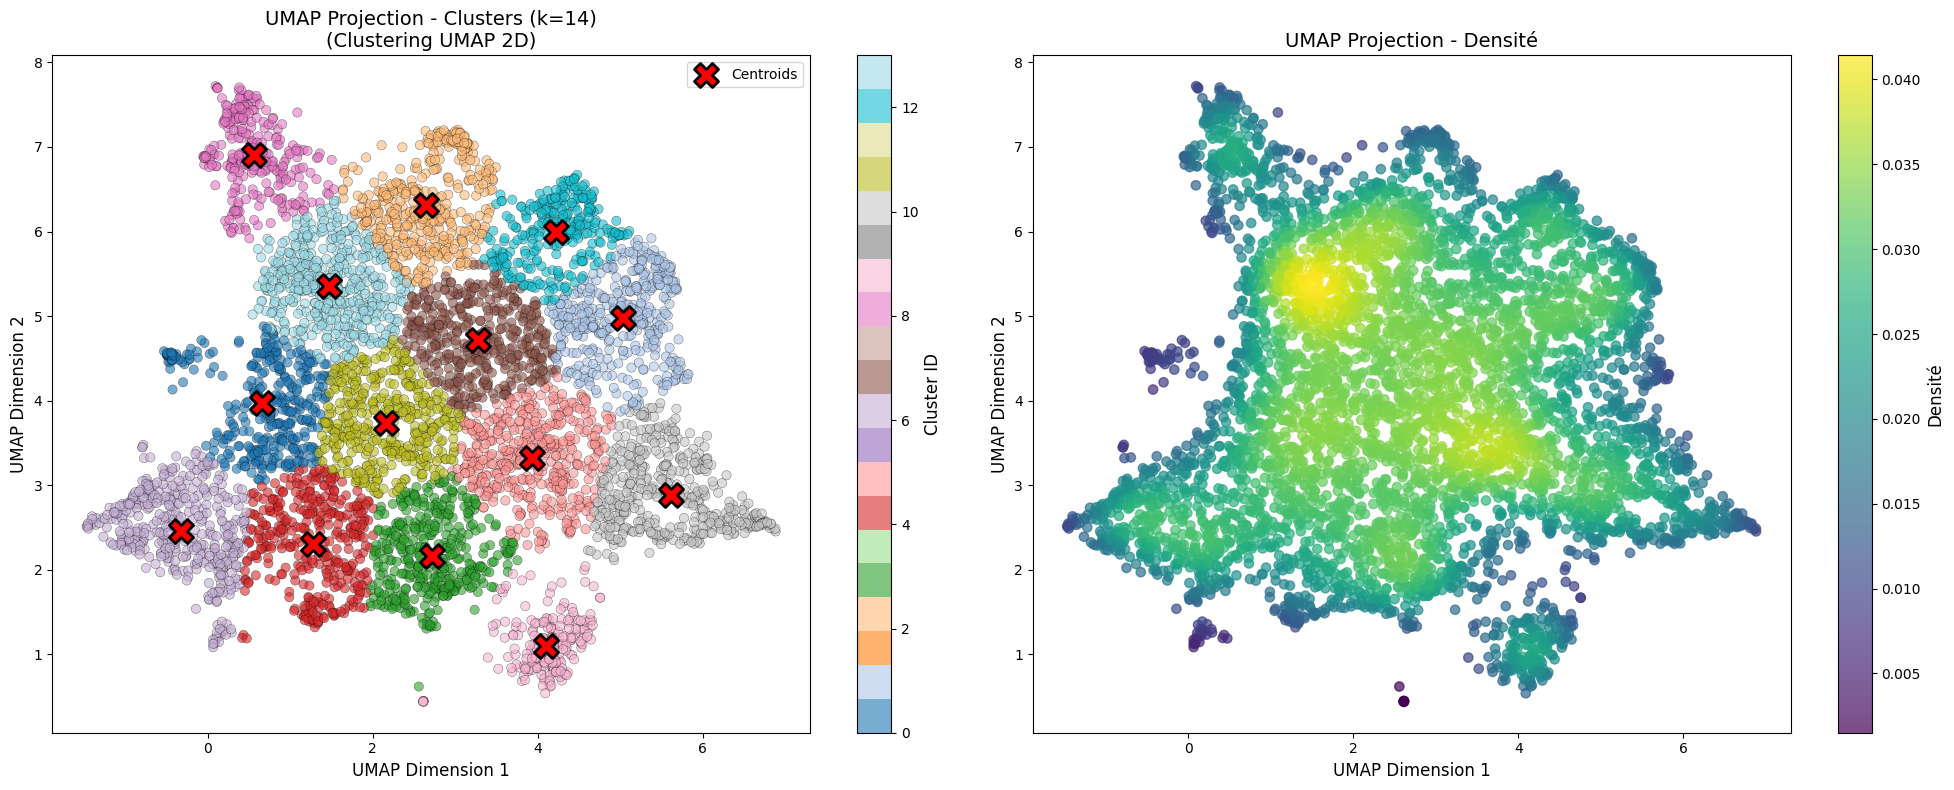

In [34]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ----------------------------
# Subplot 1: cluster 
# ----------------------------
scatter1 = axes[0].scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=df["cluster"],
    cmap="tab20",
    alpha=0.6,
    s=45,
    edgecolors="black",
    linewidth=0.3
)

axes[0].set_title(
    f"UMAP Projection - Clusters (k={best_k_2d})\n(Clustering UMAP 2D)",
    fontsize=14
)
axes[0].set_xlabel("UMAP Dimension 1", fontsize=12)
axes[0].set_ylabel("UMAP Dimension 2", fontsize=12)

cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label("Cluster ID", fontsize=12)

# Centroidi  in 2D
centroids_2d = kmeans_2d_final.cluster_centers_
axes[0].scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c="red",
    marker="X",
    s=300,
    edgecolors="black",
    linewidth=2,
    label="Centroids"
)
axes[0].legend(fontsize=10)

# ----------------------------
# Subplot 2: density
# ----------------------------
xy = embedding_2d.T
z = gaussian_kde(xy)(xy)

scatter2 = axes[1].scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=z,
    cmap="viridis",
    alpha=0.7,
    s=45
)

axes[1].set_title("UMAP Projection - Densité", fontsize=14)
axes[1].set_xlabel("UMAP Dimension 1", fontsize=12)
axes[1].set_ylabel("UMAP Dimension 2", fontsize=12)

cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label("Densité", fontsize=12)

plt.tight_layout()
plt.savefig("clusters_umap_2d_clustering.png", dpi=300, bbox_inches="tight")
plt.show()


## Dimension reduction then clustering

In [39]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import gaussian_kde

def proposition_to_vector(lemmas, model):
    vectors = [model.wv[l] for l in lemmas if l in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Embedding des propositions
X1 = np.array([
    proposition_to_vector(lemmas, best_model)
    for lemmas in df[NEW_COL]
])

print("Shape X1:", X1.shape)
# (n_propositions, 128)

Shape X1: (5554, 128)


In [40]:
import umap

print("\n UMAP: 128D → 2D")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)

X_umap = reducer.fit_transform(X1)

print("Shape X_umap:", X_umap.shape)
# (n_propositions, 2)


 UMAP: 128D → 2D


/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape X_umap: (5554, 2)


In [41]:
best_k = K_range[np.argmax(silhouette_scores)]

print(f"\n Meilleur k = {best_k}")

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=SEED,
    n_init=10,
    max_iter=300
)

df["cluster"] = kmeans_final.fit_predict(X_umap)


 Meilleur k = 6


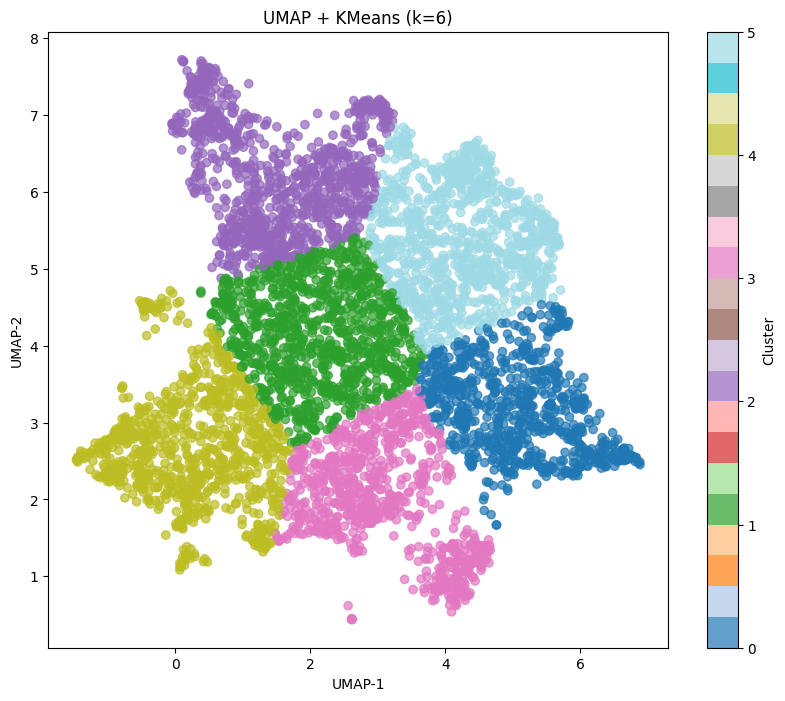

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=df["cluster"],
    cmap="tab20",
    alpha=0.7
)
plt.title(f"UMAP + KMeans (k={best_k})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd

print("\n" + "="*80)
print(" ANALYSE DÉTAILLÉE DES CLUSTERS")
print("="*80)

cluster_stats = []

# Pre-calcolo: frequenze globali (pour pondérer)
all_lemmas_global = [lemma for lemmas in df[NEW_COL] for lemma in lemmas]
global_counts = Counter(all_lemmas_global)
N_docs = len(df)

for cluster_id in sorted(df['cluster'].unique()):
    cluster_docs = df[df['cluster'] == cluster_id].copy()
    
    # ------------------------------------------------
    # 1. MOTS-CLÉS DISCRIMINANTS DU CLUSTER
    # ------------------------------------------------
    all_cluster_lemmas = [lemma for lemmas in cluster_docs[NEW_COL] for lemma in lemmas]
    cluster_counts = Counter(all_cluster_lemmas)

    # Score type TF-IDF (fréquence cluster / fréquence globale)
    keyword_scores = {
        lemma: cluster_counts[lemma] / global_counts[lemma]
        for lemma in cluster_counts
    }

    top_keywords = sorted(
        keyword_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:15]

    # ------------------------------------------------
    # 2. COHÉSION INTRA-CLUSTER (dans l’espace utilisé pour le clustering)
    # ------------------------------------------------
    cluster_vectors = X_umap[df['cluster'] == cluster_id]
    centroid = kmeans_final.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_vectors - centroid, axis=1)
    avg_distance = distances.mean()

    # ------------------------------------------------
    # 3. PROPOSITIONS LES PLUS REPRÉSENTATIVES
    # ------------------------------------------------
    cluster_docs = cluster_docs.copy()
    cluster_docs["dist_to_centroid"] = distances

    examples = cluster_docs.sort_values("dist_to_centroid").head(5)

    # ------------------------------------------------
    # 4. AFFICHAGE
    # ------------------------------------------------
    print(f"\n{'='*80}")
    print(f"🔹 CLUSTER {cluster_id} – {len(cluster_docs)} propositions "
          f"({len(cluster_docs)/len(df)*100:.1f}%)")
    print(f"{'='*80}")

    print(f" Cohésion intra-cluster (UMAP space): {avg_distance:.3f}")

    print("\n Mots-clés représentatifs du topic:")
    for i, (word, score) in enumerate(top_keywords, 1):
        print(f"   {i:2d}. {word:20s} (score={score:.3f})")

    print("\n Propositions les plus représentatives:")
    for i, (_, row) in enumerate(examples.iterrows(), 1):
        text = row[TEXT_COL][:180]
        print(f"   {i}. {text}{'...' if len(row[TEXT_COL]) > 180 else ''}")

    cluster_stats.append({
        "cluster": cluster_id,
        "size": len(cluster_docs),
        "cohesion": avg_distance,
        "top_words": ", ".join([w for w, _ in top_keywords[:5]])
    })

# ------------------------------------------------
# 5. RÉSUMÉ GLOBAL
# ------------------------------------------------
print(f"\n{'='*80}")
print(" RÉSUMÉ GLOBAL DES CLUSTERS")
print(f"{'='*80}")

stats_df = pd.DataFrame(cluster_stats)
print(stats_df.to_string(index=False))

print(f"\n Cluster le plus cohérent: {stats_df.loc[stats_df['cohesion'].idxmin(), 'cluster']}")
print(f" Cluster le plus large: {stats_df.loc[stats_df['size'].idxmax(), 'cluster']}")

In [27]:
# ========================================
# ANALYSE DES CLUSTERS
# ========================================

print("\n" + "="*80)
print(" ANALYSE DÉTAILLÉE DES CLUSTERS")
print("="*80)

cluster_stats = []
print("Clusters dans df :", sorted(df['cluster'].unique()))
print("Nombre de clusters kmeans :", kmeans_final.n_clusters)
for cluster_id in sorted(df['cluster'].unique()):
    cluster_docs = df[df['cluster'] == cluster_id]
    
    # Récupérer tous les lemmes du cluster
    all_cluster_lemmas = [lemma for lemmas in cluster_docs[NEW_COL] for lemma in lemmas]
    lemma_counts = Counter(all_cluster_lemmas)
    top_lemmas = lemma_counts.most_common(15)
    
    # Calculer la cohésion intra-cluster (distance moyenne au centroid)
    cluster_vectors = X[df['cluster'] == cluster_id]
    centroid = kmeans_final.cluster_centers_[cluster_id]
    avg_distance = np.mean([np.linalg.norm(v - centroid) for v in cluster_vectors])
    
    print(f"\n{'='*80}")
    print(f"🔹 CLUSTER {cluster_id} - {len(cluster_docs)} propositions ({len(cluster_docs)/len(df)*100:.1f}%)")
    print(f"{'='*80}")
    print(f" Cohésion intra-cluster: {avg_distance:.3f} (plus bas = plus cohérent)")
    print(f"\n Top 15 mots-clés:")
    for i, (word, count) in enumerate(top_lemmas, 1):
        print(f"   {i:2d}. {word:20s} ({count:3d} occurrences)")
    
    print(f"\n Exemples de propositions:")
    for idx, (_, row) in enumerate(cluster_docs.head(5).iterrows(), 1):
        text = row[TEXT_COL][:150]
        print(f"   {idx}. {text}{'...' if len(row[TEXT_COL]) > 150 else ''}")
    
    cluster_stats.append({
        'cluster': cluster_id,
        'size': len(cluster_docs),
        'cohesion': avg_distance,
        'top_words': ', '.join([w for w, c in top_lemmas[:5]])
    })

# Résumé global
print(f"\n{'='*80}")
print("RÉSUMÉ GLOBAL")
print(f"{'='*80}")

stats_df = pd.DataFrame(cluster_stats)
print(stats_df.to_string(index=False))

print(f"\n Cluster le plus cohérent: {stats_df.loc[stats_df['cohesion'].idxmin(), 'cluster']}")
print(f" Cluster le plus large: {stats_df.loc[stats_df['size'].idxmax(), 'cluster']}")



 ANALYSE DÉTAILLÉE DES CLUSTERS
Clusters dans df : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13)]
Nombre de clusters kmeans : 5

🔹 CLUSTER 0 - 363 propositions (6.5%)
 Cohésion intra-cluster: 0.687 (plus bas = plus cohérent)

 Top 15 mots-clés:
    1. espace               ( 86 occurrences)
    2. ville                ( 69 occurrences)
    3. biodiversité         ( 68 occurrences)
    4. commune              ( 55 occurrences)
    5. jardin               ( 55 occurrences)
    6. vert                 ( 52 occurrences)
    7. créer                ( 50 occurrences)
    8. transport            ( 50 occurrences)
    9. public               ( 44 occurrences)
   10. tout                 ( 36 occurrences)
   11. commun               ( 36 occurrences)
   12. place                ( 27 occurrences)
   13. plus                 ( 25 occurrences)
   14. favoriser

IndexError: index 5 is out of bounds for axis 0 with size 5